In [1]:
import xarray as xr
import fsspec
#import intake
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
from scipy.stats import ttest_ind, mstats

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

import dask
import pickle

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

# Set up figure

fs = fsspec.filesystem("")

In [2]:
# Location coordinates
locations = {
    'cpt': (-33.8, 18.6),
    'jhb': (-26.1, 28.0),
    'abj': (5.45, -3.9),
    'lua': (-8.994111, 13.439933)
}

names = {'cpt': 'Cape Town', 'jhb': 'Johannesburg', 'abj': 'Abidjan', 'lua': 'Luanda'}

In [3]:
def calculate_means_on_days(data, exceedance_days):
    """Calculate mean values for all hours within exceedance days."""
    # Convert exceedance days to datetime64
    exceedance_times = pd.to_datetime(exceedance_days.values)
    # Find all hours within these days
    mask = data.time.dt.floor('D').isin(exceedance_times)
    # Calculate mean across these times
    return data.where(mask).mean(dim='time')

In [4]:
path = '../create_analysis_dataset/data/'
path = 'data/'
var = 'UTCI'  # Can be changed to 'UTCI' or other heat indices
baseline_time = slice('1970', '1999')
recent_time = slice('1993', '2022')

In [5]:
results = {}

In [6]:
da = xr.open_zarr(f'{path}/heat_analysis_set.zarr')[var] - 273.15
da = da.sel(latitude = slice(20,-60))

baseline = da.sel(time = baseline_time)
recent = da.sel(time = recent_time)

threshold_90 = baseline.chunk({'time': -1}).quantile(0.99, dim='time').compute()
valid_mask = ~np.isnan(threshold_90)

#### intensity
recent_threshold = recent.chunk({'time': -1}).quantile(0.99, dim='time').compute()
recent_threshold_change = recent_threshold - threshold_90

annual_p99 = da.chunk({'time': -1}).where(valid_mask).resample(time='YE').quantile(0.99, dim='time')
baseline_annual_p99 = annual_p99.sel(time = baseline_time)
recent_annual_p99 = annual_p99.sel(time = recent_time)

significance = recent_threshold_change.to_dataset(name = '_')
significance['significance'] = (('latitude','longitude'),scipy.stats.ttest_ind(recent_annual_p99.values, baseline_annual_p99.values)[1])
significance = significance.significance
significance_mask_threshold_recent = (significance < 0.05).astype(int)


annual_p99['time'] = annual_p99['time'].dt.year - annual_p99['time'].dt.year[0]
x = annual_p99['time'].time
annual_p99 = annual_p99.chunk({'time': -1})
def theil_wrapper(y, x=x):
    if np.all(np.isnan(y)):
        return np.nan, np.nan, np.nan, np.nan
    res = mstats.theilslopes(y, x)
    return res.slope, res.intercept, res.low_slope, res.high_slope
    
slope_p99, intercept, low_slope, high_slope = xr.apply_ufunc(
    theil_wrapper,
    annual_p99,
    input_core_dims=[['time']],
    output_core_dims=[[], [], [], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float, float, float, float],
)

significant_mask_p99 = ((low_slope > 0) & (high_slope > 0)) | ((low_slope < 0) & (high_slope < 0)).astype(int)

interannual_std_p99 = annual_p99.std(dim='time', skipna=True)

# exceedence days
annual_exceed_days = (da > threshold_90).where(valid_mask).resample(time='YE').sum(dim='time', skipna=True)

mean_recent_change = annual_exceed_days.sel(time = recent_time).mean(dim='time', skipna=True) - 3.7

significance = mean_recent_change.to_dataset(name = '_')
significance['significance'] = (('latitude','longitude'),scipy.stats.ttest_ind(annual_exceed_days.sel(time = recent_time).values, annual_exceed_days.sel(time = baseline_time).values)[1])
significance = significance.significance
significance_mask_exceed_recent = (significance < 0.05).astype(int)

exceed_all = (da > threshold_90)
count_all = exceed_all.where(valid_mask).resample(time='YE').sum(dim='time', skipna=True).compute()
count_all['time'] = count_all['time'].dt.year - count_all['time'].dt.year[0]
x = count_all['time'].time

def theil_wrapper(y, x=x):
    if np.all(np.isnan(y)):
        return np.nan, np.nan, np.nan, np.nan
    res = mstats.theilslopes(y, x)
    return res.slope, res.intercept, res.low_slope, res.high_slope
    
slope_n_days, intercept, low_slope, high_slope = xr.apply_ufunc(
    theil_wrapper,
    count_all,
    input_core_dims=[['time']],
    output_core_dims=[[], [], [], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float, float, float, float],
)

significant_mask_n_days = ((low_slope > 0) & (high_slope > 0)) | ((low_slope < 0) & (high_slope < 0)).astype(int)

interannual_std_n_days = count_all.std(dim='time', skipna=True)

results[var] = {
    "Threshold_90": threshold_90.where(valid_mask).load(),
    "Threshold_Change": recent_threshold_change.where(valid_mask).load(),
    "Threshold_Significance": significance_mask_threshold_recent.where(valid_mask).load(),
    "Trend_Slope_p99": slope_p99.where(valid_mask).load()*10,
    "Trend_mask_p99": significant_mask_p99.where(valid_mask).load(),
    "Interannual_STD_p99": interannual_std_p99.where(valid_mask).load(),
    "Exceedance_Change": mean_recent_change.where(valid_mask).load(),
    "Exceedance_Significance": significance_mask_exceed_recent.where(valid_mask).load(),
    "Trend_Slope_n_days": slope_n_days.where(valid_mask).load()*10,
    "Trend_mask_n_days": significant_mask_n_days.where(valid_mask).load(),
    "Interannual_STD_n_days": interannual_std_n_days.where(valid_mask).load()
}

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/peter/.local/share/mamba/envs/som_pyt

In [7]:
min_thresh = results['UTCI']['Threshold_Change'].min().item()
max_thresh = results['UTCI']['Threshold_Change'].max().item()
min_thresh_abs = -max(abs(min_thresh), abs(max_thresh))
max_thresh_abs = max(abs(min_thresh), abs(max_thresh))

min_exc = results['UTCI']['Exceedance_Change'].min().item()
max_exc = results['UTCI']['Exceedance_Change'].max().item()
min_exc_abs = -max(abs(min_exc), abs(max_exc))
max_exc_abs = max(abs(min_exc), abs(max_exc))

In [8]:

plot_config = {
    'Threshold_90': {
        'title': "Baseline 99th Percentile",
        'vmin': 15, 'vmax': 75,
        'cmap': cmocean.cm.balance,
        'units': '°C'
    },
    'Threshold_Change': {
        'title': "Change in 99th Percentile",
        'vmin': min_thresh_abs, 'vmax': max_thresh_abs,
        'cmap': cmocean.cm.balance,
        'units': '°C'
    },
    'Trend_Slope_p99': {
        'title': "Trend in Annual 99th Percentile",
        'vmin': -1, 'vmax': 1,
        'cmap': cmocean.cm.tarn_r,
        'units': '°C/Decade'
    },
    'Interannual_STD_p99': {
        'title': "Standard Deviation\n(°C)",
        'vmin': 0, 'vmax': 2,
        'cmap': cmocean.cm.algae,
        'units': '°C'
    },
    'Exceedance_Change': {
        'title': "Change in Mean Annual # Exceedance Days",
        'vmin': min_exc_abs, 'vmax': max_exc_abs,
        'cmap': cmocean.cm.balance,
        'units': 'Days'
    },
    'Trend_Slope_n_days': {
        'title': "Trend in Exceedances",
        'vmin': -10, 'vmax': 10,  # Corrected vmin/vmax order
        'cmap': cmocean.cm.tarn_r,
        'units': 'Days/Decade'
    },
    'Interannual_STD_n_days': {
        'title': "Interannual Standard Deviation",
        'vmin': 0, 'vmax': 20,
        'cmap': cmocean.cm.algae,
        'units': 'Days'
    }
}

metrics = [
             'Threshold_Change',
             'Trend_Slope_p99',
             #'Interannual_STD_p99',
             'Exceedance_Change',
             'Trend_Slope_n_days',
             #'Interannual_STD_n_days'
]


Plotting: Threshold_Change
Plotting: Trend_Slope_p99
Plotting: Exceedance_Change
Plotting: Trend_Slope_n_days


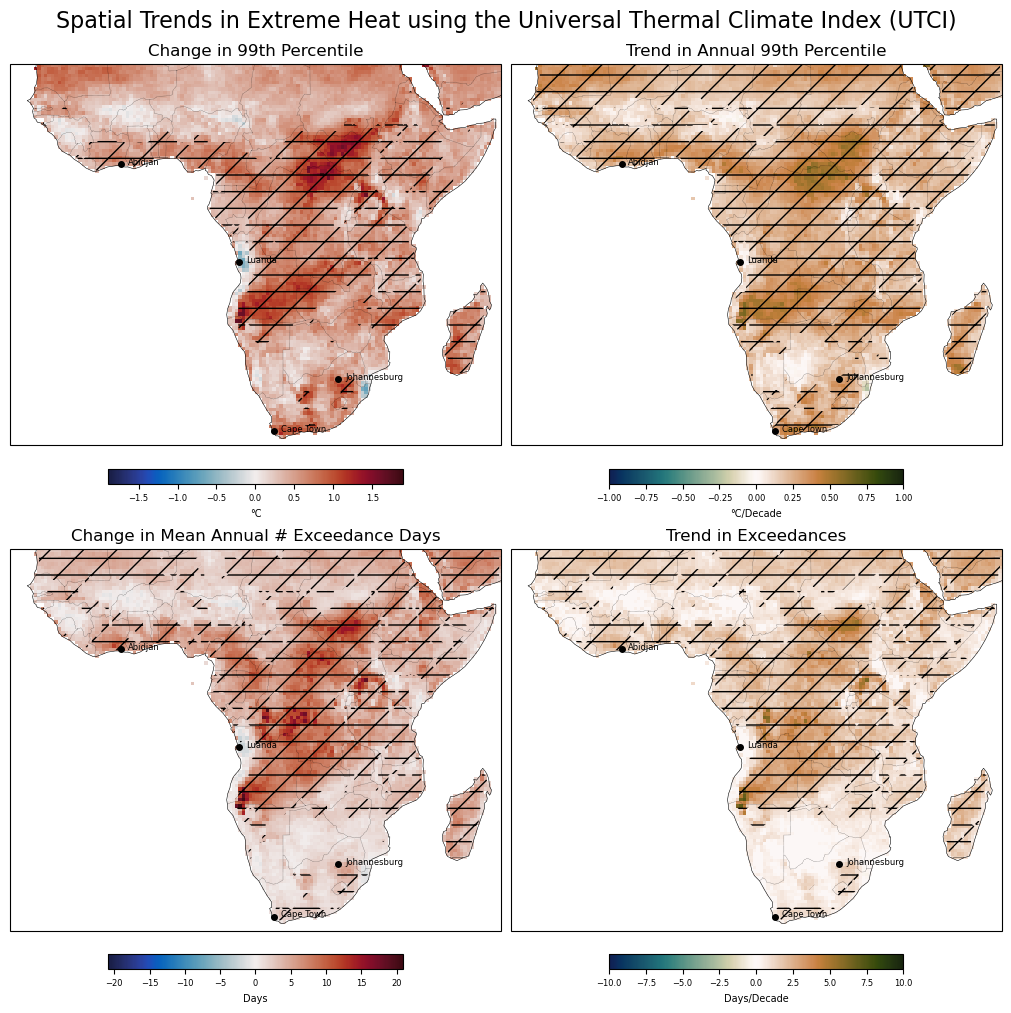

In [9]:
n_metrics = len(plot_config)
n_rows, n_cols = 2, 2
fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols,
    figsize=(10, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)
axes = axes.flatten()

# plotting loop
for idx, metric in enumerate(metrics):
    print(f"Plotting: {metric}")
    significance_data = None
    config = plot_config[metric]
    data = results[var][metric]
    ax = axes[idx]

    if 'Trend' in metric:
        if 'n_days' in metric:
            significance_data = results[var]['Trend_mask_n_days']
        else:
            significance_data = results[var]['Trend_mask_p99']
    elif metric == 'Exceedance_Change':
        significance_data = results[var]['Exceedance_Significance']
    elif metric == 'Threshold_Change':
        significance_data = results[var]['Threshold_Significance']

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=config['cmap'],
        add_colorbar=False,
        add_labels=False,
        vmin=config['vmin'],
        vmax=config['vmax']
    )

    if significance_data is not None:
        significance_data.plot.contourf(
            ax=ax,
            transform=ccrs.PlateCarree(),
            levels=[-0.5, 0.5, 1.5],
            hatches=[None, "-/"],
            colors="none",
            add_colorbar=False,
            alpha=0
        )
    
     # Add location markers
    for key, (lat, lon) in locations.items():
        ax.plot(lon, lat, marker='o', color='black', markersize=4, transform=ccrs.PlateCarree())
        ax.text(lon + 1, lat, names[key], fontsize=6, color='black', transform=ccrs.PlateCarree())


    ax.set_title(config['title'], fontsize=12)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', shrink=0.6)
    cbar.ax.tick_params(labelsize=6)
    cbar.set_label(config['units'], fontsize=7)

# Hide unused axes
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])



fig.suptitle('Spatial Trends in Extreme Heat using the Universal Thermal Climate Index (UTCI)', fontsize=16)
plt.savefig('plots/01_change_summary.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
da = xr.open_zarr(f'{path}/heat_analysis_set.zarr')[var] - 273.15

baseline = da.sel(time=slice('1980', '1999'))
prev_decade = da.sel(time=slice('2003', '2012'))
recent = da.sel(time=slice('2013', '2022'))

threshold_90 = baseline.chunk({'time': -1}).quantile(0.99, dim='time').compute()
valid_mask = ~np.isnan(threshold_90)

#### intensity

prev_decade_threshold = prev_decade.chunk({'time': -1}).quantile(0.99, dim='time').compute()
prev_decade_threshold_change = prev_decade_threshold - threshold_90

recent_threshold = recent.chunk({'time': -1}).quantile(0.99, dim='time').compute()
recent_threshold_change = recent_threshold - threshold_90

annual_p99 = da.chunk({'time': -1}).where(valid_mask).resample(time='YE').quantile(0.99, dim='time')
annual_p99['time'] = annual_p99['time'].dt.year - annual_p99['time'].dt.year[0]
x = annual_p99['time'].time
annual_p99 = annual_p99.chunk({'time': -1})
def theil_wrapper(y, x=x):
    if np.all(np.isnan(y)):
        return np.nan, np.nan, np.nan, np.nan
    res = mstats.theilslopes(y, x)
    return res.slope, res.intercept, res.low_slope, res.high_slope
    
slope_p99, intercept, low_slope, high_slope = xr.apply_ufunc(
                                                        theil_wrapper,
                                                        annual_p99,  # 3D DataArray (time, lat, lon)
                                                        input_core_dims=[['time']],
                                                        output_core_dims=[[], [], [], []],
                                                        vectorize=True,
                                                        dask='parallelized',  # if using dask
                                                        output_dtypes=[float, float, float, float],
                                                    )
significant_mask_p99 = ((low_slope > 0) & (high_slope > 0)) | ((low_slope < 0) & (high_slope < 0)).astype(int)

interannual_std_p99 = annual_p99.std(dim='time', skipna=True)

# exceedence days

exceed_prev_decade = (prev_decade > threshold_90)
count_prev_decade = exceed_prev_decade.where(valid_mask).resample(time='YE').sum(dim='time', skipna=True)
mean_prev_decade_change = count_prev_decade.mean(dim='time', skipna=True) - 3.7

exceed_recent = (recent > threshold_90)
count_recent = exceed_recent.where(valid_mask).resample(time='YE').sum(dim='time', skipna=True)
mean_recent_change = count_recent.mean(dim='time', skipna=True) - 3.7

exceed_all = (da > threshold_90)
count_all = exceed_all.where(valid_mask).resample(time='YE').sum(dim='time', skipna=True).compute()
count_all['time'] = count_all['time'].dt.year - count_all['time'].dt.year[0]
x = count_all['time'].time

# Define a function to apply theilslopes on each timeseries
def theil_wrapper(y, x=x):
    if np.all(np.isnan(y)):
        return np.nan, np.nan, np.nan, np.nan
    res = mstats.theilslopes(y, x)
    return res.slope, res.intercept, res.low_slope, res.high_slope
    
slope_n_days, intercept, low_slope, high_slope = xr.apply_ufunc(
                                                        theil_wrapper,
                                                        count_all,  # 3D DataArray (time, lat, lon)
                                                        input_core_dims=[['time']],
                                                        output_core_dims=[[], [], [], []],
                                                        vectorize=True,
                                                        dask='parallelized',  # if using dask
                                                        output_dtypes=[float, float, float, float],
                                                    )

significant_mask_n_days = ((low_slope > 0) & (high_slope > 0)) | ((low_slope < 0) & (high_slope < 0)).astype(int)

interannual_std_n_days = count_all.std(dim='time', skipna=True)

results[var] = {
    "Threshold_90": threshold_90.where(valid_mask).load(),
    "Threshold_Change_2003_2012": prev_decade_threshold_change.where(valid_mask).load(),
    "Threshold_Change_2013_2022": recent_threshold_change.where(valid_mask).load(),
    "Trend_Slope_p99": slope_p99.where(valid_mask).load()*10,
    "Trend_mask_p99": significant_mask_p99.where(valid_mask).load(),
    "Interannual_STD_p99": interannual_std_p99.where(valid_mask).load(),
    "Exceedance_Change_2003_2012": mean_prev_decade_change.where(valid_mask).load(),
    "Exceedance_Change_2013_2022": mean_recent_change.where(valid_mask).load(),
    "Trend_Slope_n_days": slope_n_days.where(valid_mask).load()*10,
    "Trend_mask_n_days": significant_mask_n_days.where(valid_mask).load(),
    "Interannual_STD_n_days": interannual_std_n_days.where(valid_mask).load()
}

min_thresh = min(results['WBGT']['Threshold_Change_2013_2022'].min(), results['WBGT']['Threshold_Change_2003_2012'].min()).item()
max_thresh = max(results['WBGT']['Threshold_Change_2013_2022'].max(), results['WBGT']['Threshold_Change_2003_2012'].max()).item()
min_thresh_abs = -max(abs(min_thresh), abs(max_thresh))
max_thresh_abs = max(abs(min_thresh), abs(max_thresh))

min_exc = min(results['WBGT']['Exceedance_Change_2013_2022'].min(), results['WBGT']['Exceedance_Change_2003_2012'].min()).item()
max_exc = max(results['WBGT']['Exceedance_Change_2013_2022'].max(), results['WBGT']['Exceedance_Change_2003_2012'].max()).item()
min_exc_abs = -max(abs(min_exc), abs(max_exc))
max_exc_abs = max(abs(min_exc), abs(max_exc))

plot_config = {
    'Threshold_90': {
        'title': "Baseline 99th Percentile",
        'vmin': 15, 'vmax': 75,
        'cmap': cmocean.cm.balance,
        'units': '°C'
    },
    'Threshold_Change_2003_2012': {
        'title': "Change in 99th Percentile\n(2003–2012)",
        'vmin': min_thresh_abs, 'vmax': max_thresh_abs,
        'cmap': cmocean.cm.balance,
        'units': '°C'
    },
    'Threshold_Change_2013_2022': {
        'title': "Change in 99th Percentile",
        'vmin': min_thresh_abs, 'vmax': max_thresh_abs,
        'cmap': cmocean.cm.balance,
        'units': '°C'
    },
    'Trend_Slope_p99': {
        'title': "Trend in Annual 99th Percentile",
        'vmin': -1, 'vmax': 1,
        'cmap': cmocean.cm.tarn_r,
        'units': '°C/Decade'
    },
    'Interannual_STD_p99': {
        'title': "Standard Deviation\n(°C)",
        'vmin': 0, 'vmax': 2,
        'cmap': cmocean.cm.algae,
        'units': '°C'
    },
    'Exceedance_Change_2003_2012': {
        'title': "Change in Mean Annual # Exceedance Days\n(2003–2012)",
        'vmin': min_exc_abs, 'vmax': max_exc_abs,
        'cmap': cmocean.cm.balance,
        'units': 'Days'
    },
    'Exceedance_Change_2013_2022': {
        'title': "Change in Mean Annual # Exceedance Days",
        'vmin': min_exc_abs, 'vmax': max_exc_abs,
        'cmap': cmocean.cm.balance,
        'units': 'Days'
    },
    'Trend_Slope_n_days': {
        'title': "Trend in Exceedances",
        'vmin': -10, 'vmax': 10,  # Corrected vmin/vmax order
        'cmap': cmocean.cm.tarn_r,
        'units': 'Days/Decade'
    },
    'Interannual_STD_n_days': {
        'title': "Interannual Standard Deviation",
        'vmin': 0, 'vmax': 20,
        'cmap': cmocean.cm.algae,
        'units': 'Days'
    }
}

metrics = [
             #'Threshold_Change_2003_2012',
             'Threshold_Change_2013_2022',
             'Trend_Slope_p99',
             'Interannual_STD_p99',
             #'Exceedance_Change_2003_2012',
             'Exceedance_Change_2013_2022',
             'Trend_Slope_n_days',
             'Interannual_STD_n_days'
]

n_metrics = len(plot_config)
n_rows, n_cols = 2, 3
fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols,
    figsize=(12, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)
axes = axes.flatten()

# Loop through metrics and plot
for idx, metric in enumerate(metrics):
    print(f"Plotting: {metric}")
    significance_data = None
    config = plot_config[metric]
    data = results[variable][metric]
    ax = axes[idx]

    if 'Trend' in metric:
        if 'n_days' in metric:
            significance_data = results[variable]['Trend_mask_n_days']
        else:
            significance_data = results[variable]['Trend_mask_p99']
        
    
    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=config['cmap'],
        add_colorbar=False,
        add_labels=False,
        vmin=config['vmin'],
        vmax=config['vmax']
    )
    if significance_data is not None:
        significance_data.plot.contourf(
                        ax=ax,
                        transform=ccrs.PlateCarree(),
                        levels=[-0.5, 0.5, 1.5],
                        hatches=[None, "-/"],
                        colors="none",
                        add_colorbar=False,
                        alpha=0
                    )
    

    ax.set_title(config['title'], fontsize=12)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', shrink=0.6)#, pad=0.045)
    cbar.ax.tick_params(labelsize=6)
    cbar.set_label(config['units'], fontsize=7) 

# Hide unused axes
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Trends and Variability in Wet Bulb Globe Temperature Extremes', fontsize=20)
plt.savefig('plots/01_change_summary.png', dpi=300, bbox_inches='tight')
plt.show()

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


KeyError: 'WBGT'

In [ ]:
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(6, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

variable = 'WBGT'
axes = axes.flatten()

# 1. Change in 99th Percentile Temperature (2013–2022)
data = results[variable]['Threshold_Change_2013_2022']
ax = axes[0]
im = data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.tarn_r,
               add_colorbar=False, add_labels=False, vmin=min_thresh_abs, vmax=max_thresh_abs)
ax.set_title("Change in 99th Percentile Temperature\n(2013–2022)", fontsize=9)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.4, pad=0.04).ax.tick_params(labelsize=6)

# 2. Trend in Annual 99th Percentile WBGT (°C/Decade)
data = results[variable]['Trend_Slope_p99']
ax = axes[1]
im = data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.balance,
               add_colorbar=False, add_labels=False, vmin=-1, vmax=1)
ax.set_title("Trend in Annual 99th Percentile WBGT\n(°C/Decade)", fontsize=9)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.4, pad=0.04).ax.tick_params(labelsize=6)

# 3. Change in Mean Annual # Exceedance Days (2013–2022)
data = results[variable]['Exceedance_Change_2013_2022']
ax = axes[2]
im = data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.tarn_r,
               add_colorbar=False, add_labels=False, vmin=min_exc_abs, vmax=max_exc_abs)
ax.set_title("Change in Mean Annual # Exceedance Days\n(2013–2022)", fontsize=9)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.4, pad=0.04).ax.tick_params(labelsize=6)

# 4. Trend in Exceedances (Days/Decade)
data = results[variable]['Trend_Slope_n_days']
ax = axes[3]
im = data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.balance,
               add_colorbar=False, add_labels=False, vmin=-10, vmax=10)
ax.set_title("Trend in Exceedances\n(Days/Decade)", fontsize=9)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.4, pad=0.04).ax.tick_params(labelsize=6)

# Final layout and saving
fig.suptitle('Extreme Heat Trends – Latest Decade (2013–2022)', fontsize=14)
plt.savefig('plots/WBGT_exceedance_summary_latest_decade.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
fig, axes = plt.subplots(
    nrows=4, ncols=2,
    figsize=(6, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

axes = axes.flatten()  # Flatten for easier indexing

variable = 'WBGT'

# 1. Change in 99th Percentile Temperature (2003–2012)
data = results[variable]['Threshold_Change_2003_2012']
ax = axes[0]
im = data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.tarn_r, add_colorbar=False, add_labels=False, vmin=min_thresh_abs, vmax=max_thresh_abs)
ax.set_title("Change in 99th Percentile Temperature\n(2003–2012)", fontsize=8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.85, pad=0.045).ax.tick_params(labelsize=6)

# 2. Change in 99th Percentile Temperature (2013–2022)
data = results[variable]['Threshold_Change_2013_2022']
ax = axes[1]
im = data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.tarn_r, add_colorbar=False, add_labels=False, vmin=min_thresh_abs, vmax=max_thresh_abs)
ax.set_title("Change in 99th Percentile Temperature\n(2013–2022)", fontsize=8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.85, pad=0.045).ax.tick_params(labelsize=6)

# 3. Trend in Annual 99th Percentile WBGT (°C/Decade)
data = results[variable]['Trend_Slope_p99']
ax = axes[2]
im = data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.balance, add_colorbar=False, add_labels=False, vmin=-1, vmax=1)
ax.set_title("Trend in Annual 99th Percentile WBGT\n(°C/Decade)", fontsize=8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.85, pad=0.045).ax.tick_params(labelsize=6)

# 4. Standard Deviation (°C)
data = results[variable]['Interannual_STD_p99']
ax = axes[3]
im = data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.algae, add_colorbar=False, add_labels=False, vmin=0, vmax=2)
ax.set_title("Standard Deviation\n(°C)", fontsize=8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.85, pad=0.045).ax.tick_params(labelsize=6)

# 5. Change in Mean Annual # Exceedance Days (2003–2012)
data = results[variable]['Exceedance_Change_2003_2012']
ax = axes[4]
im = data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.tarn_r, add_colorbar=False, add_labels=False, vmin=min_exc_abs, vmax=max_exc_abs)
ax.set_title("Change in Mean Annual # Exceedance Days\n(2003–2012)", fontsize=8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.85, pad=0.045).ax.tick_params(labelsize=6)

# 6. Change in Mean Annual # Exceedance Days (2013–2022)
data = results[variable]['Exceedance_Change_2013_2022']
ax = axes[5]
im = data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.tarn_r, add_colorbar=False, add_labels=False, vmin=min_exc_abs, vmax=max_exc_abs)
ax.set_title("Change in Mean Annual # Exceedance Days\n(2013–2022)", fontsize=8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.85, pad=0.045).ax.tick_params(labelsize=6)

# 7. Trend in Exceedances (Days/Decade)
data = results[variable]['Trend_Slope_n_days']
ax = axes[6]
im = data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.balance, add_colorbar=False, add_labels=False, vmin=-10, vmax=10)
ax.set_title("Trend in Exceedances\n(Days/Decade)", fontsize=8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.85, pad=0.045).ax.tick_params(labelsize=6)

# 8. Standard Deviation (Days)
data = results[variable]['Interannual_STD_n_days']
ax = axes[7]
im = data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.algae, add_colorbar=False, add_labels=False, vmin=0, vmax=20)
ax.set_title("Standard Deviation\n(Days)", fontsize=8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.85, pad=0.045).ax.tick_params(labelsize=6)

# Final layout and saving
fig.suptitle('Extreme Heat Metrics Overview', fontsize=20)
plt.savefig('plots/WBGT_exceedance_summary.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
metrics = list(results[variable])
metrics

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

# Define just the WBGT variable
variable = 'WBGT'
n_rows, n_cols = 4, 2
metrics = ['Threshold_90',
 'Threshold_Change_2003_2012',
 'Threshold_Change_2013_2022',
 'Trend_Slope_p99',
 'Interannual_STD_p99',
 'Exceedance_Change_2003_2012',
 'Exceedance_Change_2013_2022',
 'Trend_Slope_n_days',
 'Interannual_STD_n_days']

titles = [
    "Baseline 99th Percentile Temperature\n(1980–1999)",
    "Change in 99th Percentile Temperature\n(2003–2012)",
    "Change in 99th Percentile Temperature\n(2013–2022)",
    "Trend in Annual 99th Percentile WBGT\n(°C/Decade)",
    "Standard Deviation\n(°C)",
    "Change in Mean Annual # Exceedance Days\n(2003–2012)",
    "Change in Mean Annual # Exceedance Days\n(2013–2022)",
    "Trend in Exceedances\n(Days/Decade)",
    "Standard Deviation\n(Days)"
]
n_metrics = len(titles)

# Set up figure
fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols,
    figsize=(6, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

axes = axes.flatten()  # Flatten to simplify indexing

cmaps = [
    #cmocean.cm.thermal,
    cmocean.cm.tarn_r,
    cmocean.cm.tarn_r,
    cmocean.cm.balance,
    cmocean.cm.algae,
    cmocean.cm.tarn_r,
    cmocean.cm.tarn_r,
    cmocean.cm.balance,
    cmocean.cm.algae
]

min_thresh = min(results['WBGT']['Threshold_Change_2013_2022'].min(), results['WBGT']['Threshold_Change_2003_2012'].min()).item()
max_thresh = max(results['WBGT']['Threshold_Change_2013_2022'].max(), results['WBGT']['Threshold_Change_2003_2012'].max()).item()

min_thresh_abs = -max(abs(min_thresh), abs(max_thresh))
max_thresh_abs = max(abs(min_thresh), abs(max_thresh))

min_exc = min(results['WBGT']['Exceedance_Change_2013_2022'].min(), results['WBGT']['Exceedance_Change_2003_2012'].min()).item()
max_exc = max(results['WBGT']['Exceedance_Change_2013_2022'].max(), results['WBGT']['Exceedance_Change_2003_2012'].max()).item()

min_exc_abs = -max(abs(min_exc), abs(max_exc))
max_exc_abs = max(abs(min_exc), abs(max_exc))

vmins = [
    15,
    min_thresh_abs,
    min_thresh_abs,
    -1,
    0,
    min_exc_abs,
    min_exc_abs,
    10,
    5
]

vmaxs = [
    75,
    max_thresh_abs,
    max_thresh_abs,
    1,
    2,
    max_exc_abs,
    max_exc_abs,
    -10,
    20
]

for idx, (metric, cmap, vmin, vmax) in enumerate(zip(metrics, cmaps, vmins, vmaxs)):
    print(metric)
    data = results[variable][metric]
    idx_plot = idx
    #if idx > 0:
    #    idx_plot = idx + 3
    
    ax = axes[idx_plot]
        
    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        add_colorbar=False,
        add_labels=False,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(titles[idx], fontsize=8)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.85, pad=0.045)
    cbar.ax.tick_params(labelsize=6)

# Remove other unused axes

#fig.delaxes(axes[1])
#fig.delaxes(axes[2])
#fig.delaxes(axes[3])

fig.suptitle('Extreme Heat Metrics Overview', fontsize=20)
plt.savefig('plots/WBGT_exceedance_summary.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

# Define just the WBGT variable
variable = 'WBGT'
n_rows, n_cols = 1, 5
metrics = [x for x in list(results[variable]) if '2003' not in x]

titles = [
    "Baseline 99th Percentile Temperature\n(1980–1999)",
    "Change in 99th Percentile Temperature\n(2013–2022)",
    "Change in Mean Annual # Exceedance Days\n(2013–2022)",
    "Trend in Exceedances\n(Days/Decade)",
    "Interannual Variability\n(Days)"
]

# Set up figure
fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols,
    figsize=(12, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

axes = axes.flatten()  # Flatten to simplify indexing

cmaps = [
    cmocean.cm.thermal,
    cmocean.cm.curl,
    cmocean.cm.curl,
    cmocean.cm.balance,
    cmocean.cm.algae
]

min_thresh = results[variable]['Threshold_Change_2013_2022'].min().item()
max_thresh = results[variable]['Threshold_Change_2013_2022'].max().item()
min_thresh_abs = -max(abs(min_thresh), abs(max_thresh))
max_thresh_abs = max(abs(min_thresh), abs(max_thresh))

min_exc = results[variable]['Exceedance_Change_2013_2022'].min().item()
max_exc = results[variable]['Exceedance_Change_2013_2022'].max().item()
min_exc_abs = -max(abs(min_exc), abs(max_exc))
max_exc_abs = max(abs(min_exc), abs(max_exc))

vmins = [
    15,
    min_thresh_abs,
    min_exc_abs,
    -0.05,
    5
]

vmaxs = [
    75,
    max_thresh_abs,
    max_exc_abs,
    0.05,
    65
]

for idx, (metric, cmap, vmin, vmax) in enumerate(zip(metrics, cmaps, vmins, vmaxs)):
    data = results[variable][metric]
    idx_plot = idx
    
    ax = axes[idx_plot]

    # Apply 10x scaling for trend (row 6)
    if idx == 3:
        data = data * 10
        
    if idx not in [1,2]:
        im = data.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            add_colorbar=False,
            add_labels=False,
        )
    else:
        im = data.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            add_colorbar=False,
            add_labels=False,
            vmin=vmin,
            vmax=vmax
        )

    ax.set_title(titles[idx], fontsize=8)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")

    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', shrink=0.75, pad = -0.1)
    cbar.ax.tick_params(labelsize=6)


fig.suptitle('WBGT – Extreme Heat Metrics Overview', fontsize=20)

plt.savefig('plots/WBGT_exceedance_summary.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
min(results['WBGT']['Threshold_Change_2013_2022'].min(), results['WBGT']['Threshold_Change_2003_2012'].min()).item()

In [ ]:
results['WBGT']['Threshold_Change_2003_2012'].max()

In [ ]:
results['WBGT']['Threshold_Change_2003_2012'].max()

In [ ]:
# Variables
variable = 'WBGT'
var_title = 'WBGT'
titles = [
    "Baseline 99th Percentile Temperature\n(1980–1999)",
    "Change in 99th Percentile Temperature\n(2003–2012)",
    "Change in 99th Percentile Temperature\n(2013–2022)",
    "Change in Mean Annual # Exceedance Days\n(2003–2012)",
    "Change in Mean Annual # Exceedance Days\n(2013–2022)",
    "Trend in Exceedances\n(Days/Decade)",
    "Interannual Variability\n(Days)"
]
metrics = list(results[variable])

# Setup
fig, axes = plt.subplots(
    nrows=3, ncols=2,
    figsize=(10, 15),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)

# Flatten axes for easier indexing
axes = axes.flatten()

# Define color maps and vmin/vmax values
cmaps = [
    cmocean.cm.thermal,
    cmocean.cm.curl,
    cmocean.cm.curl,
    cmocean.cm.curl,
    cmocean.cm.curl,
    cmocean.cm.balance,
    cmocean.cm.algae
]
vmins = [15, 15, 15, -65, -65, -0.05, 5]
vmaxs = [75, 75, 75, 65, 65, 0.05, 65]

# Plot only the baseline (metric 0)
data = results[variable][metrics[0]]
ax = axes[0]

im = data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmaps[0],
    add_colorbar=False,
    add_labels=False,
    vmin=vmins[0],
    vmax=vmaxs[0]
)

# Add title and features
ax.set_title(titles[0], fontsize=16)
#ax.text(-0.1, 0.5, titles[0], transform=ax.transAxes,
#        fontsize=14, rotation=90, va='center', ha='center')
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")

# Add colorbar
cbar = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.8, pad=0.045)
cbar.ax.tick_params(labelsize=12)

# Remove other unused axes
for i in range(1, 6):
    fig.delaxes(axes[i])

fig.suptitle('WBGT Baseline 99th Percentile Heat Metric\n(1980–1999)', fontsize=20)
plt.savefig('plots/wbgt_baseline_only.png', dpi=300, bbox_inches='tight')
plt.show()